    In this notebook we will use the functions already discussed in earlier notebooks and construct the hamiltonian for BdG calculations.
    While these functions already exists in the modules, we include it here to understand it

In [1]:
using LinearAlgebra
# using PyCall
using CSV
using DataFrames
using Plots
using DelimitedFiles
# @pyimport numpy as np

In [2]:
# Importing personal modules
include("src/bdg_utilities.jl")
include("src/general_utils.jl")

Main.GeneralUtils

In [3]:
# Loading personal modules
# using .BdGUtilities: generate_t_map, extract_geometry, build_H_twisted, generate_t_matrix
using .BdGUtilities: generate_t_map, extract_geometry, generate_t_matrix
using .GeneralUtils: fermi_fn, show_all, show_matrix

f = fermi_fn

fermi_fn (generic function with 2 methods)

In [4]:
"""
    create_bdg_ham_up(deltaList, H, mu, nSites, nUp, nDn, U, impuritySite, J;
                      K=0, isComplex=false, include_hartree=false)

2n x 2n BdG Hamiltonian for the decoupled sector in the basis (c_up; c_dn^dagger).

Optionally includes Hartree shifts (U*nDn on the up-particle block, U*nUp on the down-hole block).
"""
function create_bdg_ham_up(
    deltaList, H, mu, nSites, nUp, nDn, U, impuritySite, J;
    K=0, isComplex=false, include_hartree::Bool=false
)
    sigmaUp = 1
    sigmaDn = -1

    HBdG = isComplex ? zeros(ComplexF64, 2nSites, 2nSites) : zeros(Float64, 2nSites, 2nSites)

    # ----- particle block diagonal: c↑ -----
    for i in 1:nSites
        hart = include_hartree ? (U * nDn[i]) : 0.0
        if i == impuritySite
            H[i, i] = -(mu + hart + (K - sigmaUp * J))
        else
            H[i, i] = -(mu + hart)
        end
    end

    # Fill particle/hole blocks from H
    @inbounds for i in 1:nSites, j in 1:nSites
        hij = H[i, j]
        HBdG[i, j] = hij
        HBdG[nSites + i, nSites + j] = -conj(hij)
    end

    # Pairing (onsite singlet)
    @inbounds for i in 1:nSites
        Δi = deltaList[i]
        HBdG[i, nSites + i] = Δi
        HBdG[nSites + i, i] = conj(Δi)
    end

    # ----- hole block diagonal: c↓† -----
    # This overwrites the diagonal of the lower-right block to include µ, Hartree, impurities.
    @inbounds for i in 1:nSites
        hart = include_hartree ? (U * nUp[i]) : 0.0
        if i == impuritySite
            HBdG[nSites + i, nSites + i] = (mu + hart + (K - sigmaDn * J))
        else
            HBdG[nSites + i, nSites + i] = (mu + hart)
        end
    end

    return HBdG
end



"""
    create_bdg_ham_dn(deltaList, H, mu, nSites, nUp, nDn, U, impuritySite, J;
                      K=0, isComplex=false, include_hartree=false)

2n x 2n BdG Hamiltonian for the decoupled sector in the basis (c_dn; c_up^dagger).

Optionally includes Hartree shifts (U*nUp on the down-particle block, U*nDn on the up-hole block).
"""
function create_bdg_ham_dn(
    deltaList, H, mu, nSites, nUp, nDn, U, impuritySite, J;
    K=0, isComplex=false, include_hartree::Bool=false
)
    sigmaUp = 1
    sigmaDn = -1

    HBdG = isComplex ? zeros(ComplexF64, 2nSites, 2nSites) : zeros(Float64, 2nSites, 2nSites)

    # ----- particle block diagonal: c↓ -----
    for i in 1:nSites
        hart = include_hartree ? (U * nUp[i]) : 0.0
        if i == impuritySite
            H[i, i] = -(mu + hart + (K - sigmaDn * J))
        else
            H[i, i] = -(mu + hart)
        end
    end

    # Fill particle/hole blocks from H
    @inbounds for i in 1:nSites, j in 1:nSites
        hij = H[i, j]
        HBdG[i, j] = hij
        HBdG[nSites + i, nSites + j] = -conj(hij)
    end

    # Pairing
    @inbounds for i in 1:nSites
        Δi = deltaList[i]
        HBdG[i, nSites + i] = Δi
        HBdG[nSites + i, i] = conj(Δi)
    end

    # ----- hole block diagonal: c↑† -----
    @inbounds for i in 1:nSites
        hart = include_hartree ? (U * nDn[i]) : 0.0
        if i == impuritySite
            HBdG[nSites + i, nSites + i] = (mu + hart + (K - sigmaUp * J))
        else
            HBdG[nSites + i, nSites + i] = (mu + hart)
        end
    end

    return HBdG
end

create_bdg_ham_dn

In [5]:
"""
Build the full spinful 4n x 4n BdG Hamiltonian in the basis

(c1_up ... cn_up; c1_dn^dagger ... cn_dn^dagger; c1_dn ... cn_dn; c1_up^dagger ... cn_up^dagger).

This function first constructs the spinful normal-state Hamiltonian, including
Rashba SOC and, if supplied, intrinsic SOC. It then adds onsite singlet pairing,
forms the standard BdG matrix, and finally reorders it into the basis above.

Arguments
- `deltaList`: onsite superconducting gap values for each site
- `H`: spinless n x n tight-binding matrix
- `mu`: chemical potential
- `nSites`: number of lattice sites
- `nUp`, `nDn`: spin-up and spin-down densities, used only if Hartree terms are included
- `U`: Hubbard interaction strength, used only if Hartree terms are included
- `impuritySite`: impurity site index (1-based, or `0` if there is no impurity)
- `J`: magnetic impurity strength
- `x`, `y`: site coordinates
- `neighbors`: bond list used to build the SOC terms
- `lambda`: Rashba SOC strength
- `tMap`: dictionary of bond-dependent hoppings `(i,j) => t_ij`

Keyword arguments
- `K=0.0`: non-magnetic impurity strength
- `include_hartree=false`: if `true`, adds Hartree shifts `-U*n_{-sigma}` to the particle sector
- `isoMap=nothing`: optional intrinsic SOC sign map `(i,j) => nu_ij`
- `lambdaIso=0.0`: intrinsic SOC strength

Returns
- `Hfull`: the full 4n x 4n BdG Hamiltonian
"""
function create_bdg_ham_full(deltaList, H, mu, nSites, nUp, nDn, U, impuritySite, J,
                             x, y, neighbors, lambda, tMap;
                             K=0.0, include_hartree::Bool=false,
                             isoMap=nothing, lambdaIso=0.0)

    n = nSites
    @assert length(deltaList) == n
    @assert size(H,1) == n && size(H,2) == n

    # choose element type
    T = promote_type(eltype(H), eltype(deltaList), ComplexF64)

    h = zeros(T, 2n, 2n)

    h[1:n,     1:n    ] .= T.(H)
    h[n+1:2n,  n+1:2n ] .= T.(H)

    # add chemical potential + impurities (+ optional Hartree)
    for i in 1:n
        # impurity shifts: diagonal particle term is -(mu + (K - σ J)) at impurity, else -mu
        # σ = +1 for up, -1 for down
        v_up = -mu
        v_dn = -mu

        if impuritySite != 0 && i == impuritySite
            v_up = -(mu + (K - (+1)*J))
            v_dn = -(mu + (K - (-1)*J))
        end

        if include_hartree
            v_up -= U * nDn[i]
            v_dn -= U * nUp[i]
        end

        h[i,i]       += v_up
        h[n+i,n+i]   += v_dn
    end

    # Rashba SOC: off-diagonal spin-flip blocks
    if lambda != 0.0
        for i in 1:n
            xi, yi = x[i], y[i]
            for j in neighbors[i]
                tij = get(tMap, (i,j), 0.0)
                tij == 0.0 && continue

                dx = x[j] - xi
                dy = y[j] - yi

                S = (-im) * lambda * tij * (-dy - im*dx)

                h[i,   n+j] += S
                h[n+j, i  ] += conj(S)
            end
        end
    end

    if isoMap !== nothing && lambdaIso != 0.0
        for (key, ν) in isoMap
            i, j = key
            term = im * lambdaIso * ν
            h[i, j]       += term
            h[n+i, n+j]   -= term
            h[j, i]       += conj(term)
            h[n+j, n+i]   -= conj(term)
        end
    end

    # Singlet onsite delta (2nx2n) in basis (c_up; c_dn)
    Δ = zeros(T, 2n, 2n)
    for i in 1:n
        Δi = T(deltaList[i])
        Δ[i,   n+i] =  Δi
        Δ[n+i, i  ] = -Δi
    end

    # BdG in basis (c_up,c_dn, c_up^dagger,c_dn^dagger)
    HB = zeros(T, 4n, 4n)
    HB[1:2n,     1:2n    ] .= h
    HB[1:2n,     2n+1:4n ] .= Δ
    HB[2n+1:4n,  1:2n    ] .= adjoint(Δ)
    HB[2n+1:4n,  2n+1:4n ] .= -transpose(h)

    perm = vcat(1:n, 3n+1:4n, n+1:2n, 2n+1:3n)
    Hfull = HB[perm, perm]

    return Hfull
end

create_bdg_ham_full

In [6]:
function build_H_twisted(x::Vector{Float64},
                         neighbors::Vector{Vector{Int}},
                         tMap::Dict{Tuple{Int,Int},Float64},
                         twist::Float64)

    nSites = length(x)
    H = zeros(ComplexF64, nSites, nSites)

    xmin, xmax = minimum(x), maximum(x)
    Lx = xmax - xmin

    for i in 1:nSites
        xi = x[i]
        for j in neighbors[i]
            tij = get(tMap, (i,j), 0.0)
            tij == 0.0 && continue

            dx = x[j] - xi
            dx -= round(dx / Lx) * Lx

            phase = exp(1im * twist * dx / Lx)
            hij = tij * phase

            H[i, j] = hij
            H[j, i] = conj(hij)
        end
    end

    return H, Lx
end

build_H_twisted (generic function with 1 method)

In [7]:
function create_bdg_ham_full_twisted(deltaList, mu, nSites, nUp, nDn, U, impuritySite, J,
                                     x, y, neighbors, lambda, tMap;
                                     twist=0.0, Lx=nothing, K=0.0,
                                     include_hartree::Bool=false,
                                     isoMap=nothing, lambdaIso=0.0)

    n = nSites
    T = promote_type(eltype(deltaList), ComplexF64)

    # twisted spinless hopping matrix H
    Hhop, Lx_val = build_H_twisted(x, neighbors, tMap, twist)

    h = zeros(T, 2n, 2n)
    h[1:n,    1:n   ] .= T.(Hhop)
    h[n+1:2n, n+1:2n] .= T.(Hhop)

    # on-site terms (mu, impurities, optional Hartree)
    for i in 1:n
        v_up = -mu
        v_dn = -mu

        if impuritySite != 0 && i == impuritySite
            v_up = -(mu + (K - (+1)*J))
            v_dn = -(mu + (K - (-1)*J))
        end

        if include_hartree
            v_up -= U * nDn[i]
            v_dn -= U * nUp[i]
        end

        h[i,i]     += v_up
        h[n+i,n+i] += v_dn
    end

    # Rashba SOC WITH the same twist phase on the bond i->j
    if lambda != 0.0
        for i in 1:n
            xi, yi = x[i], y[i]
            for j in neighbors[i]
                tij = get(tMap, (i,j), 0.0)
                tij == 0.0 && continue

                dx = x[j] - xi
                dy = y[j] - yi
                dx -= round(dx / Lx_val) * Lx_val

                phase = exp(1im * twist * dx / Lx_val)

                S0 = (-im) * lambda * tij * (-dy - im*dx)
                S  = S0 * phase

                h[i,   n+j] += S
                h[n+j, i  ] += conj(S)
            end
        end
    end

    if isoMap !== nothing && lambdaIso != 0.0
        for (key, ν) in isoMap
            i, j = key
            dx = x[j] - x[i]
            dx -= round(dx / Lx_val) * Lx_val
            phase = exp(1im * twist * dx / Lx_val)

            term = (im * lambdaIso * ν) * phase
            h[i, j]     += term
            h[j, i]     += conj(term)
            h[n+i,n+j]  -= term
            h[n+j,n+i]  -= conj(term)
        end
    end

    # singlet onsite delta
    Δ = zeros(T, 2n, 2n)
    for i in 1:n
        Δi = T(deltaList[i])
        Δ[i,   n+i] =  Δi
        Δ[n+i, i  ] = -Δi
    end

    HB = zeros(T, 4n, 4n)
    HB[1:2n,     1:2n    ] .= h
    HB[1:2n,     2n+1:4n ] .= Δ
    HB[2n+1:4n,  1:2n    ] .= adjoint(Δ)
    HB[2n+1:4n,  2n+1:4n ] .= -transpose(h)

    perm = vcat(1:n, 3n+1:4n, n+1:2n, 2n+1:3n)
    return HB[perm, perm]
end

create_bdg_ham_full_twisted (generic function with 1 method)

In [8]:
N             = 2
nSites        = 4 * N ^ 2

nUp          = ones(Float64, nSites)
nDn          = ones(Float64, nSites)

df = CSV.read("data/N$(N)/raw_df_square-octagon$N.csv", DataFrame)

x, y, neighbors = extract_geometry(df)
lambda = 0.01
lambda_iso = 0.0
t2 = 1.0

tMap = generate_t_map(neighbors, t2=t2)
twist = 0.0

iso_map = nothing

if lambda == 0.0 && twist == 0.0
    deltaOld      = 0.7 * ones(Float64, nSites)
    isComplexCalc = false
else
    deltaOld      = 0.7 * ones(ComplexF64, nSites)
    isComplexCalc = true
end

impuritySite  = 3
mu             = -0.2
U             = 3

J             = 0.0
K             = 0.0
T             = 0.0

tMatFileName = "data/N$(N)/ham_$(N)_t2_$(t2)"
tMat = generate_t_matrix(tMatFileName); ## One doesn't need to use prebuilt hamiltonian. dataframe is enough to construct this matrix

In [9]:
H1 = create_bdg_ham_up(deltaOld, copy(tMat), mu, nSites, nUp, nDn, U, impuritySite, J;
                       isComplex=isComplexCalc, include_hartree=false)

H2 = create_bdg_ham_dn(deltaOld, copy(tMat), mu, nSites, nUp, nDn, U, impuritySite, J;
                       isComplex=isComplexCalc, include_hartree=false)

32×32 Matrix{ComplexF64}:
 0.2+0.0im  1.0+0.0im  1.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 1.0+0.0im  0.2+0.0im  1.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 1.0+0.0im  1.0+0.0im  0.2+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 1.0+0.0im  1.0+0.0im  1.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 1.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
    ⋮                             ⋱   

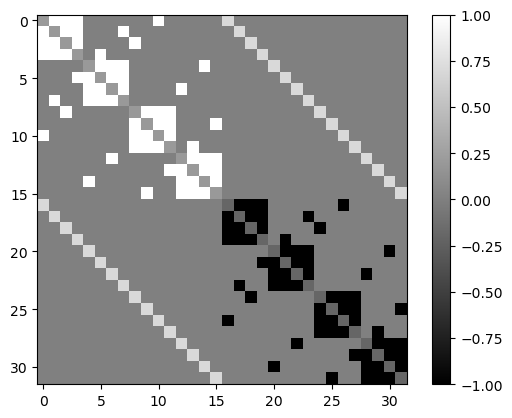

In [10]:
show_matrix(real(H2))

In [11]:
Hfull = create_bdg_ham_full(
    deltaOld, tMat, mu, nSites, nUp, nDn, U, impuritySite, J,
    x, y, neighbors, lambda, tMap;
    K=K, include_hartree=false, isoMap=iso_map, lambdaIso=lambda_iso
)

64×64 Matrix{ComplexF64}:
 0.2+0.0im  1.0+0.0im  1.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 1.0+0.0im  0.2+0.0im  1.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 1.0+0.0im  1.0+0.0im  0.2+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 1.0+0.0im  1.0+0.0im  1.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 1.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
    ⋮                             ⋱   

In [12]:
function phs_error(H, nSites)
    N = nSites
    Iₙ = Matrix{ComplexF64}(undef, N, N)
    for i in 1:N, j in 1:N
        Iₙ[i,j] = (i == j) ? 1.0 + 0im : 0.0 + 0im
    end
    Z = zeros(ComplexF64, N, N)

    Xi = [ Z  Z  Z  Iₙ;
           Z  Z  Iₙ Z;
           Z  Iₙ Z  Z;
           Iₙ Z  Z  Z ]

    return norm(Xi * conj(H) * Xi + H) / max(norm(H), 1e-30)
end

phs_error(Hfull, nSites)

0.0

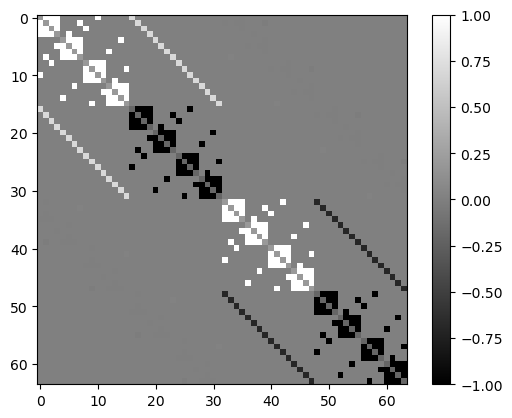

In [13]:
show_matrix(real(Hfull))

In [14]:
# twist = 0.175
twist = 0.0
Htwisted, Lx = build_H_twisted(x, neighbors, tMap, twist)

(ComplexF64[0.0 + 0.0im 1.0 - 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 1.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; … ; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 1.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 1.0 - 0.0im 0.0 + 0.0im], 1.5857860000000001)

In [15]:
# show_all(Htwisted)

In [16]:
HtwistedFull = create_bdg_ham_full_twisted(
    deltaOld, mu, nSites,
    nUp, nDn, U, impuritySite, J,
    x, y, neighbors, lambda, tMap;
    twist=twist, K=K, include_hartree=false, isoMap=iso_map, lambdaIso=lambda_iso
)

64×64 Matrix{ComplexF64}:
 0.2+0.0im  1.0-0.0im  1.0-0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 1.0+0.0im  0.2+0.0im  1.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 1.0+0.0im  1.0-0.0im  0.2+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 1.0-0.0im  1.0-0.0im  1.0-0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 1.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
    ⋮                             ⋱   

In [17]:
HtwistedFull == Hfull

false

In [18]:
Hfull = create_bdg_ham_full_twisted(
    deltaOld, mu, nSites, nUp, nDn, U, impuritySite, J,
    x, y, neighbors, 0.01, tMap;
    twist=0.1, K=K, include_hartree=false, isoMap=iso_map, lambdaIso=lambda_iso
)

HtwistedFull = create_bdg_ham_full_twisted(
    deltaOld, mu, nSites, nUp, nDn, U, impuritySite, J,
    x, y, neighbors, 0.01, tMap;
    twist=0.1, K=K, include_hartree=false, isoMap=iso_map, lambdaIso=lambda_iso
)

64×64 Matrix{ComplexF64}:
      0.2+0.0im        0.999829-0.0184688im  …        0.0+0.0im
 0.999829+0.0184688im       0.2+0.0im                 0.0+0.0im
      1.0+0.0im        0.999829-0.0184688im           0.0+0.0im
 0.999829-0.0184688im  0.999318-0.0369314im           0.0+0.0im
      0.0+0.0im             0.0+0.0im                 0.0+0.0im
      0.0+0.0im             0.0+0.0im        …        0.0+0.0im
      0.0+0.0im             0.0+0.0im                 0.0+0.0im
      0.0+0.0im             1.0+0.0im                 0.0+0.0im
      0.0+0.0im             0.0+0.0im                 0.0+0.0im
      0.0+0.0im             0.0+0.0im                 0.0+0.0im
      1.0+0.0im             0.0+0.0im        …        0.0+0.0im
      0.0+0.0im             0.0+0.0im                 0.0+0.0im
      0.0+0.0im             0.0+0.0im                 0.0+0.0im
         ⋮                                   ⋱  
      0.0-0.0im             0.0-0.0im                -0.0-0.0im
      0.0-0.0im             0

In [19]:
Hfull == HtwistedFull

true